In [1]:
import os
import pandas as pd
import numpy as np
import glob
import skbio
from skbio.stats.composition import clr
from skbio.diversity import beta_diversity
from skbio import DistanceMatrix
import plotly.graph_objects as go
from skbio import diversity
from skbio.diversity import alpha_diversity
from skbio.diversity import beta_diversity

# Raw breacken data

In [2]:
map_df=pd.read_csv("/lustre/home/babluuniba2022/JUNE_2024/KRAKEN_BRACKEN_2025/kraken2/all_map/output_map/combine_map_bracken.tsv",sep="\t")
map_df

,#Classification,DRR042264_bracken_species.k2report,DRR042265_bracken_species.k2report,DRR042266_bracken_species.k2report,DRR042267_bracken_species.k2report,DRR042268_bracken_species.k2report,DRR042269_bracken_species.k2report,DRR042270_bracken_species.k2report,DRR042271_bracken_species.k2report,DRR042272_bracken_species.k2report,...,SRR6474308_bracken_species.k2report,SRR6474309_bracken_species.k2report,SRR6474310_bracken_species.k2report,SRR6474311_bracken_species.k2report,SRR6474312_bracken_species.k2report,SRR6474313_bracken_species.k2report,SRR6474314_bracken_species.k2report,SRR6474315_bracken_species.k2report,SRR6474316_bracken_species.k2report,SRR6474317_bracken_species.k2report
0,x__Bacteria,7794037,6429729,833628,636805,896216,354098,371419,372452,12224284,...,27389338,16838951,32902146,20249512,31426228,39284233,23439582,28908015,7571423,23268469
1,x__Bacteria|p__Bdellovibrionota,0,0,0,0,0,0,0,0,0,...,0,0,0,0,14,0,13,0,0,0
2,x__Bacteria|p__Bdellovibrionota|c__Bdellovibri...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,14,0,13,0,0,0
3,x__Bacteria|p__Bdellovibrionota|c__Bdellovibri...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,14,0,13,0,0,0
4,x__Bacteria|p__Bdellovibrionota|c__Bdellovibri...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,14,0,13,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6121,x__Archaea|p__Methanobacteriota|c__Methanobact...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,37
6122,x__Archaea|p__Methanobacteriota|c__Methanobact...,0,0,0,0,0,0,0,0,0,...,0,0,48,0,0,0,0,0,14,18229
6123,x__Archaea|p__Methanobacteriota|c__Methanobact...,0,0,0,0,0,0,0,0,0,...,469,43,36,123,180,59,19,50,14,65
6124,x__Archaea|p__Methanobacteriota|c__Methanobact...,0,0,12,0,0,0,17,0,0,...,0,0,0,0,0,881,0,0,0,43


In [3]:
import pandas as pd

map_df.columns = [col.replace('_bracken_species.k2report', '') for col in map_df.columns]

taxonomic_levels = ['x__', 'p__', 'c__', 'o__', 'f__', 'g__', 's__']
taxa_cols = ['Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

taxa_dict = {level: [] for level in taxa_cols}

def parse_taxonomy(classification):
    taxa = {level: '' for level in taxa_cols}
    levels = classification.split('|')
    for level in levels:
        for i, prefix in enumerate(taxonomic_levels):
            if level.startswith(prefix):
                taxa[taxa_cols[i]] = level.replace(prefix, '')
    return taxa

for classification in map_df['#Classification']:
    taxa = parse_taxonomy(classification)
    for level in taxa_cols:
        taxa_dict[level].append(taxa[level] if taxa[level] else None)

result_df = pd.concat([pd.DataFrame(taxa_dict), map_df.drop('#Classification', axis=1)], axis=1)
result_df = result_df[result_df['Domain'] == 'Bacteria']
result_df


,Domain,Phylum,Class,Order,Family,Genus,Species,DRR042264,DRR042265,DRR042266,...,SRR6474308,SRR6474309,SRR6474310,SRR6474311,SRR6474312,SRR6474313,SRR6474314,SRR6474315,SRR6474316,SRR6474317
0,Bacteria,None,None,None,None,None,None,7794037,6429729,833628,...,27389338,16838951,32902146,20249512,31426228,39284233,23439582,28908015,7571423,23268469
1,Bacteria,Bdellovibrionota,None,None,None,None,None,0,0,0,...,0,0,0,0,14,0,13,0,0,0
2,Bacteria,Bdellovibrionota,Bdellovibrionia_A,None,None,None,None,0,0,0,...,0,0,0,0,14,0,13,0,0,0
3,Bacteria,Bdellovibrionota,Bdellovibrionia_A,CAIPTA01,None,None,None,0,0,0,...,0,0,0,0,14,0,13,0,0,0
4,Bacteria,Bdellovibrionota,Bdellovibrionia_A,CAIPTA01,CAIPTA01,None,None,0,0,0,...,0,0,0,0,14,0,13,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6064,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii_A,5477,4646,776,...,359,362,1357,14,516,424,330,1555,186,1006
6065,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003526955,5909,5165,524,...,607,270,171760,0,12188,390,975,3218,184,37325
6066,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003438075,16405,14436,1342,...,1443,398,30826,138,5733,1695,8242,4254,632,7791
6067,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii,257666,219945,23072,...,23014,10873,134862,70,64897,7399,48282,120966,4172,47731


In [9]:
metadata=pd.read_csv("../Data_Analysis/META_DATA_JUNE_10452.tsv",sep="\t")
run_ids_in_metadata = metadata["Run_ID"].unique()


taxonomy_cols = ['Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
available_run_ids = list(set(run_ids_in_metadata) & set(result_df.columns))

filtered_result_df = result_df[taxonomy_cols + available_run_ids]
filtered_result_df

,Domain,Phylum,Class,Order,Family,Genus,Species,ERR9830102,DRR042591,SRR23883114,...,ERR2017640,SRR2145528,SRR1761700,ERR481084,ERR527082,SRR28565219,ERR10906291,ERR479174,ERR2738751,ERR1913262
0,Bacteria,Bdellovibrionota,Bdellovibrionia_A,CAIPTA01,CAIPTA01,MGYG000003389,MGYG000003389,0,0,0,...,0,0,19,0,0,0,0,13,0,0
1,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,CADBRU01,CADBRU01_sp900762815,0,0,0,...,0,0,40,0,0,0,0,0,0,0
2,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,CADBRU01,MGYG000001768,19,0,0,...,0,0,0,0,0,0,12,0,0,0
3,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,UBA1436,UBA1436_sp900540405,0,0,0,...,0,0,406,0,0,0,0,0,0,0
4,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,UBA1436,UBA1436_sp002329395,0,0,0,...,0,0,543,0,0,0,0,0,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4597,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii_A,143,617,12,...,8503,0,617,66,836,0,258,3772,157,0
4598,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003526955,0,165623,102,...,14678,0,402,77,200774,0,163,14947,0,71
4599,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003438075,1079,35372,190,...,58146,0,2661,405,34539,0,410,7705,0,43
4600,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii,29,1548,24,...,1372292,0,3004,4854,1242,22,105,218628,0,765


In [20]:
result_df = filtered_result_df[filtered_result_df['Species'].notna()]
result_df.to_csv("combine_bracken_with_map_details_2025.tsv", sep="\t", index=False)
result_df

,Domain,Phylum,Class,Order,Family,Genus,Species,ERR9830102,DRR042591,SRR23883114,...,ERR2017640,SRR2145528,SRR1761700,ERR481084,ERR527082,SRR28565219,ERR10906291,ERR479174,ERR2738751,ERR1913262
0,Bacteria,Bdellovibrionota,Bdellovibrionia_A,CAIPTA01,CAIPTA01,MGYG000003389,MGYG000003389,0,0,0,...,0,0,19,0,0,0,0,13,0,0
1,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,CADBRU01,CADBRU01_sp900762815,0,0,0,...,0,0,40,0,0,0,0,0,0,0
2,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,CADBRU01,MGYG000001768,19,0,0,...,0,0,0,0,0,0,12,0,0,0
3,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,UBA1436,UBA1436_sp900540405,0,0,0,...,0,0,406,0,0,0,0,0,0,0
4,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,UBA1436,UBA1436_sp002329395,0,0,0,...,0,0,543,0,0,0,0,0,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4597,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii_A,143,617,12,...,8503,0,617,66,836,0,258,3772,157,0
4598,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003526955,0,165623,102,...,14678,0,402,77,200774,0,163,14947,0,71
4599,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003438075,1079,35372,190,...,58146,0,2661,405,34539,0,410,7705,0,43
4600,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii,29,1548,24,...,1372292,0,3004,4854,1242,22,105,218628,0,765


# Open all the Map files...

In [21]:
df_preview = pd.read_csv("combine_bracken_with_map_details_2025.tsv", sep="\t")
df_preview


,Domain,Phylum,Class,Order,Family,Genus,Species,ERR9830102,DRR042591,SRR23883114,...,ERR2017640,SRR2145528,SRR1761700,ERR481084,ERR527082,SRR28565219,ERR10906291,ERR479174,ERR2738751,ERR1913262
0,Bacteria,Bdellovibrionota,Bdellovibrionia_A,CAIPTA01,CAIPTA01,MGYG000003389,MGYG000003389,0,0,0,...,0,0,19,0,0,0,0,13,0,0
1,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,CADBRU01,CADBRU01_sp900762815,0,0,0,...,0,0,40,0,0,0,0,0,0,0
2,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,CADBRU01,MGYG000001768,19,0,0,...,0,0,0,0,0,0,12,0,0,0
3,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,UBA1436,UBA1436_sp900540405,0,0,0,...,0,0,406,0,0,0,0,0,0,0
4,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,UBA1436,UBA1436_sp002329395,0,0,0,...,0,0,543,0,0,0,0,0,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4597,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii_A,143,617,12,...,8503,0,617,66,836,0,258,3772,157,0
4598,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003526955,0,165623,102,...,14678,0,402,77,200774,0,163,14947,0,71
4599,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003438075,1079,35372,190,...,58146,0,2661,405,34539,0,410,7705,0,43
4600,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii,29,1548,24,...,1372292,0,3004,4854,1242,22,105,218628,0,765


In [24]:
df_bacteria = df_preview[df_preview["Domain"] == "Bacteria"]

sample_columns = df_bacteria.columns[7:]

bacterial_read_counts = df_bacteria[sample_columns].sum(axis=0)

# Optional: Convert to DataFrame and sort
bacterial_read_counts_df = bacterial_read_counts.reset_index()
bacterial_read_counts_df.columns = ['Run_ID', 'Total_Bacterial_Reads']
bacterial_read_counts_df = bacterial_read_counts_df.sort_values(by='Total_Bacterial_Reads', ascending=False)

print(bacterial_read_counts_df)

           Run_ID  Total_Bacterial_Reads
7854  ERR11779480              122196765
6871  ERR11779431              116340839
6345  ERR11779526              106113626
2755  ERR11779462              103666493
4508  ERR11779483              102640208
...           ...                    ...
4543    ERR162923                     29
1810   SRR5128740                     26
1207   SRR5128929                     24
2547   SRR5128387                     18
4562   SRR5128471                     16

[9672 rows x 2 columns]


In [26]:
# Assuming `bacterial_reads_df` has a column 'Total_Bacterial_Reads'
desc = bacterial_read_counts_df['Total_Bacterial_Reads'].describe()

count = int(desc['count'])
mean = round(desc['mean'], 2)
std = round(desc['std'], 2)
min_val = int(desc['min'])
q25 = int(desc['25%'])
median = int(desc['50%'])
q75 = int(desc['75%'])
max_val = int(desc['max'])

# Print nicely
print(f"Total Samples: {count}")
print(f"Mean: {mean}")
print(f"Standard Deviation: {std}")
print(f"Minimum: {min_val}")
print(f"25th Percentile (Q1): {q25}")
print(f"Median (Q2): {median}")
print(f"75th Percentile (Q3): {q75}")
print(f"Maximum: {max_val}")


Total Samples: 9672
Mean: 17779362.93
Standard Deviation: 17530490.38
Minimum: 16
25th Percentile (Q1): 4053477
Median (Q2): 10988669
75th Percentile (Q3): 31326975
Maximum: 122196765


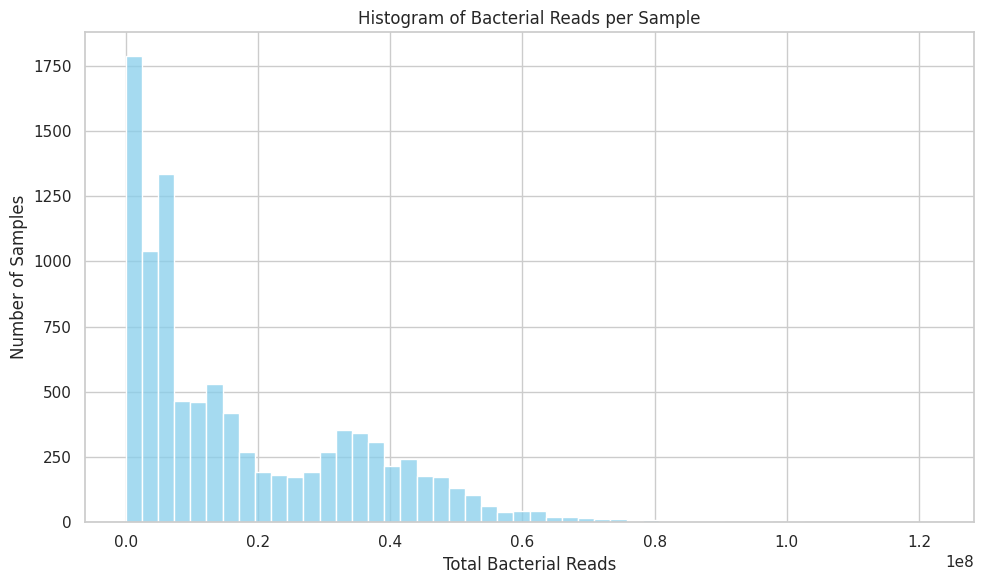

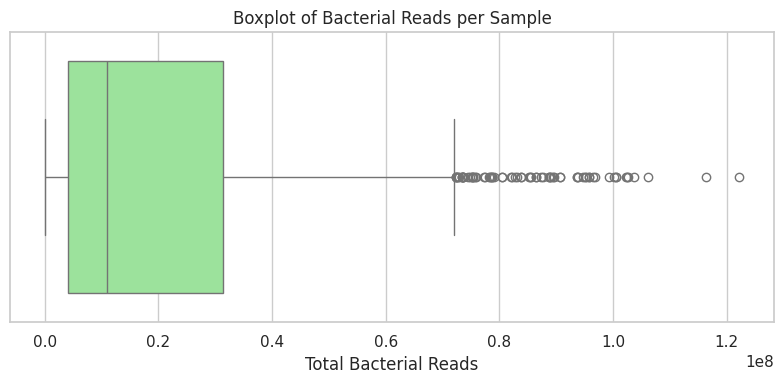

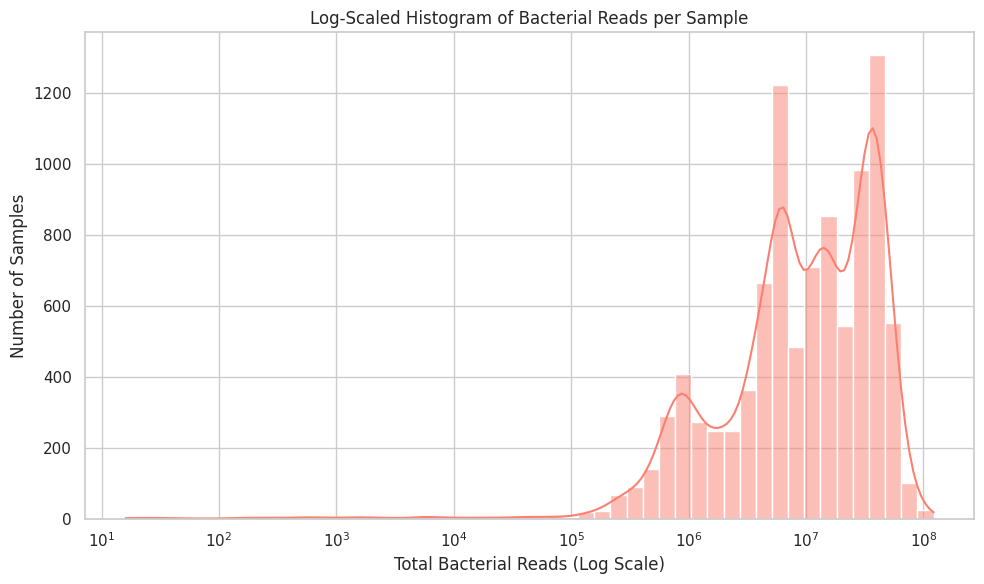

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your result (assuming from previous step)
bacterial_reads_df = bacterial_read_counts_df.copy()

# Set the plot style
sns.set(style="whitegrid")

# ---------- 1. Histogram ----------
plt.figure(figsize=(10, 6))
sns.histplot(bacterial_reads_df['Total_Bacterial_Reads'], bins=50, kde=False, color='skyblue')
plt.title("Histogram of Bacterial Reads per Sample")
plt.xlabel("Total Bacterial Reads")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

# ---------- 2. Boxplot ----------
plt.figure(figsize=(8, 4))
sns.boxplot(x=bacterial_reads_df['Total_Bacterial_Reads'], color='lightgreen')
plt.title("Boxplot of Bacterial Reads per Sample")
plt.xlabel("Total Bacterial Reads")
plt.tight_layout()
plt.show()

# ---------- 3. Log-Scaled Histogram ----------
plt.figure(figsize=(10, 6))
sns.histplot(bacterial_reads_df['Total_Bacterial_Reads'], bins=50, kde=True, color='salmon', log_scale=(True, False))
plt.title("Log-Scaled Histogram of Bacterial Reads per Sample")
plt.xlabel("Total Bacterial Reads (Log Scale)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()


In [30]:
sample_cols = df_bacteria.columns[7:]

total_reads_per_sample = df_bacteria[sample_cols].sum(axis=0)
filtered_sample_cols = total_reads_per_sample[total_reads_per_sample >= 100000].index.tolist()

taxonomy_cols = df_preview.columns[:7].tolist()
filtered_df = df_preview[taxonomy_cols + filtered_sample_cols]
filtered_df

,Domain,Phylum,Class,Order,Family,Genus,Species,ERR9830102,DRR042591,SRR23883114,...,SRR5650167,ERR2017640,SRR1761700,ERR481084,ERR527082,SRR28565219,ERR10906291,ERR479174,ERR2738751,ERR1913262
0,Bacteria,Bdellovibrionota,Bdellovibrionia_A,CAIPTA01,CAIPTA01,MGYG000003389,MGYG000003389,0,0,0,...,0,0,19,0,0,0,0,13,0,0
1,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,CADBRU01,CADBRU01_sp900762815,0,0,0,...,0,0,40,0,0,0,0,0,0,0
2,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,CADBRU01,MGYG000001768,19,0,0,...,0,0,0,0,0,0,12,0,0,0
3,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,UBA1436,UBA1436_sp900540405,0,0,0,...,0,0,406,0,0,0,0,0,0,0
4,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,UBA1436,UBA1436_sp002329395,0,0,0,...,0,0,543,0,0,0,0,0,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4597,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii_A,143,617,12,...,249,8503,617,66,836,0,258,3772,157,0
4598,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003526955,0,165623,102,...,227,14678,402,77,200774,0,163,14947,0,71
4599,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003438075,1079,35372,190,...,1350,58146,2661,405,34539,0,410,7705,0,43
4600,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii,29,1548,24,...,76614,1372292,3004,4854,1242,22,105,218628,0,765


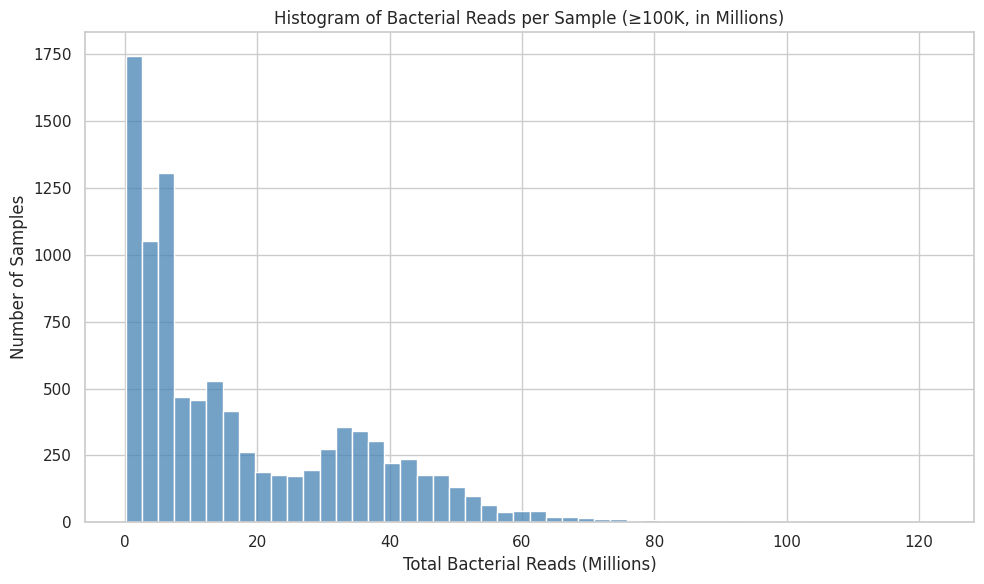

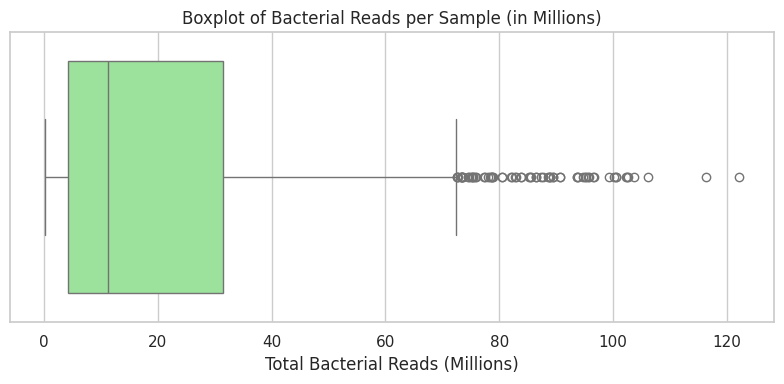

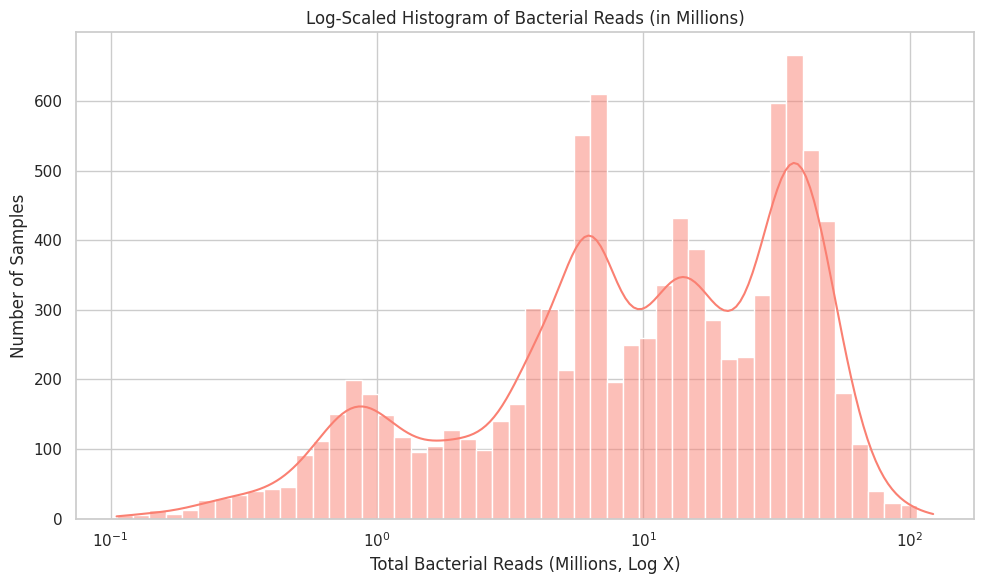

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
sample_cols = filtered_df.columns[7:]
df_bacteria_filtered = filtered_df[filtered_df["Domain"] == "Bacteria"]
total_reads_filtered = df_bacteria_filtered[sample_cols].sum(axis=0)

# Convert to DataFrame and scale to millions
reads_df = total_reads_filtered.reset_index()
reads_df.columns = ['Run_ID', 'Total_Bacterial_Reads']
reads_df['Reads_in_Million'] = reads_df['Total_Bacterial_Reads'] / 1e6

# Set plot style
sns.set(style="whitegrid")

# ---------- 1. Histogram ----------
plt.figure(figsize=(10, 6))
sns.histplot(reads_df['Reads_in_Million'], bins=50, kde=False, color='steelblue')
plt.title("Histogram of Bacterial Reads per Sample (≥100K, in Millions)")
plt.xlabel("Total Bacterial Reads (Millions)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

# ---------- 2. Boxplot ----------
plt.figure(figsize=(8, 4))
sns.boxplot(x=reads_df['Reads_in_Million'], color='lightgreen')
plt.title("Boxplot of Bacterial Reads per Sample (in Millions)")
plt.xlabel("Total Bacterial Reads (Millions)")
plt.tight_layout()
plt.show()

# ---------- 3. Log-Scaled Histogram ----------
plt.figure(figsize=(10, 6))
sns.histplot(reads_df['Reads_in_Million'], bins=50, kde=True, color='salmon', log_scale=(True, False))
plt.title("Log-Scaled Histogram of Bacterial Reads (in Millions)")
plt.xlabel("Total Bacterial Reads (Millions, Log X)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()


In [32]:
# Step 1: Get all taxonomy columns
taxonomy_cols = filtered_df.columns[:7]  # ['Domain', 'Phylum', ..., 'Species']

drop_tax_cols = [col for col in taxonomy_cols if col != 'Species']

# Step 3: Drop those columns
filtered_df_species_only = filtered_df.drop(columns=drop_tax_cols)


filtered_df_species_only


,Species,ERR9830102,DRR042591,SRR23883114,SRR11047639,SRR2155176,SRR413668,ERR1398259,ERR1190697,ERR479055,...,SRR5650167,ERR2017640,SRR1761700,ERR481084,ERR527082,SRR28565219,ERR10906291,ERR479174,ERR2738751,ERR1913262
0,MGYG000003389,0,0,0,0,0,0,0,0,0,...,0,0,19,0,0,0,0,13,0,0
1,CADBRU01_sp900762815,0,0,0,0,0,0,0,0,0,...,0,0,40,0,0,0,0,0,0,0
2,MGYG000001768,19,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,12,0,0,0
3,UBA1436_sp900540405,0,0,0,0,0,0,0,0,0,...,0,0,406,0,0,0,0,0,0,0
4,UBA1436_sp002329395,0,0,0,0,0,0,0,0,0,...,0,0,543,0,0,0,0,0,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4597,Ruminococcus_E_bromii_A,143,617,12,69,555,118,29,0,2897,...,249,8503,617,66,836,0,258,3772,157,0
4598,Ruminococcus_E_sp003526955,0,165623,102,0,53,49,29,17,3933,...,227,14678,402,77,200774,0,163,14947,0,71
4599,Ruminococcus_E_sp003438075,1079,35372,190,37,231,772,143,0,52601,...,1350,58146,2661,405,34539,0,410,7705,0,43
4600,Ruminococcus_E_bromii,29,1548,24,0,23,94,1628,0,271371,...,76614,1372292,3004,4854,1242,22,105,218628,0,765


In [33]:
#how many samples per samples

# Step 1: Select sample columns (all except 'Species')
sample_cols = filtered_df_species_only.columns.drop('Species')

# Step 2: For each sample, count species with read count > 0
species_per_sample = (filtered_df_species_only[sample_cols] > 0).sum(axis=0)

# Convert to DataFrame for easy viewing
species_per_sample_df = species_per_sample.reset_index()
species_per_sample_df.columns = ['Run_ID', 'Species_Count']

# Print first few samples
print(species_per_sample_df.head())

# Optional: Summary stats
print(species_per_sample_df['Species_Count'].describe())


        Run_ID  Species_Count
0   ERR9830102           1925
1    DRR042591           2585
2  SRR23883114           2759
3  SRR11047639           1650
4   SRR2155176           2708
count    9602.00000
mean     2483.81431
std       872.97725
min       230.00000
25%      1806.00000
50%      2547.50000
75%      3185.00000
max      4448.00000
Name: Species_Count, dtype: float64


In [40]:
filtered_df_species_only.index=filtered_df_species_only["Species"].values
filtered_df_species_only_df=filtered_df_species_only.drop(columns="Species")
filtered_df_species_only_df

,ERR9830102,DRR042591,SRR23883114,SRR11047639,SRR2155176,SRR413668,ERR1398259,ERR1190697,ERR479055,ERR527155,...,SRR5650167,ERR2017640,SRR1761700,ERR481084,ERR527082,SRR28565219,ERR10906291,ERR479174,ERR2738751,ERR1913262
MGYG000003389,0,0,0,0,0,0,0,0,0,0,...,0,0,19,0,0,0,0,13,0,0
CADBRU01_sp900762815,0,0,0,0,0,0,0,0,0,0,...,0,0,40,0,0,0,0,0,0,0
MGYG000001768,19,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,12,0,0,0
UBA1436_sp900540405,0,0,0,0,0,0,0,0,0,0,...,0,0,406,0,0,0,0,0,0,0
UBA1436_sp002329395,0,0,0,0,0,0,0,0,0,0,...,0,0,543,0,0,0,0,0,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ruminococcus_E_bromii_A,143,617,12,69,555,118,29,0,2897,1396,...,249,8503,617,66,836,0,258,3772,157,0
Ruminococcus_E_sp003526955,0,165623,102,0,53,49,29,17,3933,485,...,227,14678,402,77,200774,0,163,14947,0,71
Ruminococcus_E_sp003438075,1079,35372,190,37,231,772,143,0,52601,1541,...,1350,58146,2661,405,34539,0,410,7705,0,43
Ruminococcus_E_bromii,29,1548,24,0,23,94,1628,0,271371,47556,...,76614,1372292,3004,4854,1242,22,105,218628,0,765


In [41]:
otu_table=filtered_df_species_only_df.T
otu_table

,MGYG000003389,CADBRU01_sp900762815,MGYG000001768,UBA1436_sp900540405,UBA1436_sp002329395,UBA1436_sp900541355,UBA1174_sp900556855,Fibrobacter_A_intestinalis,HGM14224_sp900761905,UBA4248_sp004554395,...,MGYG000003112,Ruminococcus_E_sp003521625,Ruminococcus_E_sp002493635,Ruminococcus_E_sp900543095,Ruminococcus_E_sp900755995,Ruminococcus_E_bromii_A,Ruminococcus_E_sp003526955,Ruminococcus_E_sp003438075,Ruminococcus_E_bromii,Ruminococcus_E_bromii_B
ERR9830102,0,0,19,0,0,0,0,0,0,0,...,789,0,115,0,46,143,0,1079,29,60
DRR042591,0,0,0,0,0,0,0,0,0,19,...,637,110,414,785,2516,617,165623,35372,1548,959
SRR23883114,0,0,0,0,0,0,12,0,0,0,...,0,0,66,0,126,12,102,190,24,83
SRR11047639,0,0,0,0,0,0,0,0,0,0,...,169,0,15,0,16,69,0,37,0,23
SRR2155176,0,0,0,0,0,0,0,0,0,17,...,133,0,389,18,289,555,53,231,23,89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR28565219,0,0,0,0,0,0,0,0,0,0,...,11,0,10,0,0,0,0,0,22,60
ERR10906291,0,0,12,0,0,0,0,0,1061,0,...,89,18,71,34,689,258,163,410,105,90
ERR479174,13,0,0,0,0,0,0,0,230,0,...,1591,778,1663,1645,4477,3772,14947,7705,218628,576146
ERR2738751,0,0,0,0,10,0,0,0,0,0,...,250,0,88,0,12,157,0,0,0,27


In [43]:
otu_meta=pd.merge(otu_table,metadata,left_index=True,right_on="Run_ID")
otu_meta

,MGYG000003389,CADBRU01_sp900762815,MGYG000001768,UBA1436_sp900540405,UBA1436_sp002329395,UBA1436_sp900541355,UBA1174_sp900556855,Fibrobacter_A_intestinalis,HGM14224_sp900761905,UBA4248_sp004554395,...,Phenotype,Full_Name,Sex,Age,Location,Sample,Platform,BMI,Author,Class_Label
6973,0,0,19,0,0,0,0,0,0,0,...,Healthy,Healthy,MALE,45,USA,Stool,Illumina NextSeq 550,"230,449,827","Boktor et al.,(2023)",0
327,0,0,0,0,0,0,0,0,0,19,...,Obesity,Obesity,MALE,54,Japan,Stool,Illumina,22.4,"Nishijima et al,2016)",1
8762,0,0,0,0,0,0,12,0,0,0,...,UC,Ulcerative Colitis,MALE,NaN,Korea,Stool,MGIseq system,NaN,"Kang et al.,(2023)",1
7097,0,0,0,0,0,0,0,0,0,0,...,RA,Rheumatoid arthritis,FEMALE,64,USA,Stool,Illumina HiSeq 4000,NaN,"Gupta et al,2021)",1
8342,0,0,0,0,0,0,0,0,0,17,...,Obesity,Obesity,NaN,NaN,Germany,Stool,Illumina HiSeq 2500,NaN,"Louis et al,2016)",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9240,0,0,0,0,0,0,0,0,0,0,...,UC,Ulcerative Colitis,MALE,65,USA,Stool,Illumina NovaSeq X,NaN,"E. Krueger et al.,(2024)",1
615,0,0,12,0,0,0,0,0,1061,0,...,Healthy,Healthy,FEMALE,21,France,Stool,ION_TORRENT,21.6,"Fan et al.,(2023)",0
4952,13,0,0,0,0,0,0,0,230,0,...,CRC,Colorectal Cancer,MALE,65,France,Stool,Illumina HiSeq 2000,24,"Zeller et al.,(2014)",1
3986,0,0,0,0,10,0,0,0,0,0,...,ABx,Antibiotic exposer,NaN,NaN,Canada,Stool,Illumina,NaN,"Raymond et al,2019)",1


In [70]:
# Count number of samples per BioProject
bioproject_counts = otu_meta["BioProject"].value_counts()

# Get BioProjects with at least 10 samples
bioprojects_to_keep = bioproject_counts[bioproject_counts >= 10].index

# Filter otu_meta to keep only these BioProjects
filtered_otu_meta = otu_meta[otu_meta["BioProject"].isin(bioprojects_to_keep)]

# Optional: Check results
print(filtered_otu_meta["BioProject"].value_counts())


BioProject
PRJEB6070       1278
PRJEB28237       841
PRJEB51776       591
PRJNA834801      488
PRJNA945504      479
PRJDB3601        399
PRJEB17784       362
PRJEB21528       351
PRJNA422434      349
SRP057027        344
PRJEB6337        305
PRJEB7774        305
PRJEB36300       302
PRJEB27928       258
PRJEB12123       254
PRJEB8094        237
PRJNA375935      210
PRJEB13870       189
PRJNA385949      161
PRJEB1786        126
PRJEB10878       126
PRJEB53401       118
PRJEB57770       116
PRJNA893901      105
PRJNA1096686      96
PRJNA328899       94
PRJNA290729       92
PRJEB35615        90
PRJNA305507       87
PRJNA1065874      64
PRJNA762484       55
PRJEB12947        53
PRJNA397112       52
PRJNA268964       51
PRJNA598446       47
PRJNA46321        44
PRJNA648321       43
PRJEB18755        42
PRJEB7949         40
PRJNA942468       38
PRJEB19090        37
PRJNA299502       37
PRJNA278393       37
PRJNA319574       35
PRJNA821541       30
PRJNA743718       26
PRJNA832737       25
PR

In [71]:
filtered_otu_meta["Platform"].value_counts()

Platform
Illumina                       2462
Illumina HiSeq 2000            1945
ION_TORRENT                     767
Illumina NovaSeq 6000           710
MGIseq system                   479
Illumina Hiseq4000              362
Illumina Genome Analyzer II     349
Illumina HiSeq                  344
Illumina HiSeq X                332
Illumina HiSeq 4000             305
LS454                           202
Illumina HiSeq 3000             176
Illumina HiSeq 2500             132
Illumina NextSeq 550            118
Illumina Hiseq2500              113
Illumina MiSeq                  105
Illumina NovaSeq X               96
Illumina NextSeq 500             95
llumina NextSeq and HiSeq        87
Illumina GAIIx                   37
Illumina HiSeq2000               25
Name: count, dtype: int64

In [72]:
illumina_platforms = filtered_otu_meta['Platform'].str.contains('Illumina', case=False, na=False)
filtered_otu_meta = filtered_otu_meta[illumina_platforms]
filtered_otu_meta

,MGYG000003389,CADBRU01_sp900762815,MGYG000001768,UBA1436_sp900540405,UBA1436_sp002329395,UBA1436_sp900541355,UBA1174_sp900556855,Fibrobacter_A_intestinalis,HGM14224_sp900761905,UBA4248_sp004554395,...,Phenotype,Full_Name,Sex,Age,Location,Sample,Platform,BMI,Author,Class_Label
6973,0,0,19,0,0,0,0,0,0,0,...,Healthy,Healthy,MALE,45,USA,Stool,Illumina NextSeq 550,"230,449,827","Boktor et al.,(2023)",0
327,0,0,0,0,0,0,0,0,0,19,...,Obesity,Obesity,MALE,54,Japan,Stool,Illumina,22.4,"Nishijima et al,2016)",1
7097,0,0,0,0,0,0,0,0,0,0,...,RA,Rheumatoid arthritis,FEMALE,64,USA,Stool,Illumina HiSeq 4000,NaN,"Gupta et al,2021)",1
8342,0,0,0,0,0,0,0,0,0,17,...,Obesity,Obesity,NaN,NaN,Germany,Stool,Illumina HiSeq 2500,NaN,"Louis et al,2016)",1
9746,0,0,0,0,0,0,0,0,0,0,...,Healthy,Healthy,MALE,45,China,Stool,Illumina Genome Analyzer II,NaN,"Qin et al,2012)",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6098,0,0,0,0,0,0,79,0,7292,24,...,Healthy,Healthy,FEMALE,32,China,Stool,Illumina,20.32,"Qin et al.,(2014)",0
9240,0,0,0,0,0,0,0,0,0,0,...,UC,Ulcerative Colitis,MALE,65,USA,Stool,Illumina NovaSeq X,NaN,"E. Krueger et al.,(2024)",1
4952,13,0,0,0,0,0,0,0,230,0,...,CRC,Colorectal Cancer,MALE,65,France,Stool,Illumina HiSeq 2000,24,"Zeller et al.,(2014)",1
3986,0,0,0,0,10,0,0,0,0,0,...,ABx,Antibiotic exposer,NaN,NaN,Canada,Stool,Illumina,NaN,"Raymond et al,2019)",1


In [73]:
filtered_otu_meta["BioProject"].value_counts()

BioProject
PRJEB6070       1278
PRJEB28237       841
PRJNA834801      488
PRJEB17784       362
PRJNA422434      349
SRP057027        344
PRJEB6337        305
PRJEB7774        305
PRJEB36300       302
PRJEB27928       258
PRJEB12123       254
PRJEB8094        237
PRJNA375935      210
PRJEB13870       189
PRJNA385949      161
PRJEB10878       126
PRJEB1786        126
PRJEB53401       118
PRJEB57770       116
PRJNA893901      105
PRJNA1096686      96
PRJNA328899       94
PRJNA290729       92
PRJEB35615        90
PRJDB3601         64
PRJNA1065874      64
PRJNA762484       55
PRJEB12947        53
PRJNA397112       52
PRJNA268964       51
PRJNA598446       47
PRJNA648321       43
PRJEB18755        42
PRJEB7949         40
PRJNA942468       38
PRJEB19090        37
PRJNA278393       37
PRJNA299502       37
PRJNA319574       35
PRJNA821541       30
PRJNA743718       26
PRJNA832737       25
PRJNA177201       25
PRJEB13835        23
PRJNA373879       19
PRJEB7331         16
PRJNA46321         1
Na

In [74]:
bioprojects_to_keep = filtered_otu_meta["BioProject"].value_counts()[lambda x: x >= 10].index #PRJNA46321 having less then 1 samples.
filtered_otu_meta = filtered_otu_meta[filtered_otu_meta["BioProject"].isin(bioprojects_to_keep)]
filtered_otu_meta

,MGYG000003389,CADBRU01_sp900762815,MGYG000001768,UBA1436_sp900540405,UBA1436_sp002329395,UBA1436_sp900541355,UBA1174_sp900556855,Fibrobacter_A_intestinalis,HGM14224_sp900761905,UBA4248_sp004554395,...,Phenotype,Full_Name,Sex,Age,Location,Sample,Platform,BMI,Author,Class_Label
6973,0,0,19,0,0,0,0,0,0,0,...,Healthy,Healthy,MALE,45,USA,Stool,Illumina NextSeq 550,"230,449,827","Boktor et al.,(2023)",0
327,0,0,0,0,0,0,0,0,0,19,...,Obesity,Obesity,MALE,54,Japan,Stool,Illumina,22.4,"Nishijima et al,2016)",1
7097,0,0,0,0,0,0,0,0,0,0,...,RA,Rheumatoid arthritis,FEMALE,64,USA,Stool,Illumina HiSeq 4000,NaN,"Gupta et al,2021)",1
8342,0,0,0,0,0,0,0,0,0,17,...,Obesity,Obesity,NaN,NaN,Germany,Stool,Illumina HiSeq 2500,NaN,"Louis et al,2016)",1
9746,0,0,0,0,0,0,0,0,0,0,...,Healthy,Healthy,MALE,45,China,Stool,Illumina Genome Analyzer II,NaN,"Qin et al,2012)",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6098,0,0,0,0,0,0,79,0,7292,24,...,Healthy,Healthy,FEMALE,32,China,Stool,Illumina,20.32,"Qin et al.,(2014)",0
9240,0,0,0,0,0,0,0,0,0,0,...,UC,Ulcerative Colitis,MALE,65,USA,Stool,Illumina NovaSeq X,NaN,"E. Krueger et al.,(2024)",1
4952,13,0,0,0,0,0,0,0,230,0,...,CRC,Colorectal Cancer,MALE,65,France,Stool,Illumina HiSeq 2000,24,"Zeller et al.,(2014)",1
3986,0,0,0,0,10,0,0,0,0,0,...,ABx,Antibiotic exposer,NaN,NaN,Canada,Stool,Illumina,NaN,"Raymond et al,2019)",1


In [75]:
filtered_otu_meta["Location"].value_counts()

Location
China             1777
USA               1391
Germany           1079
Canada            1078
France             958
Austria            305
Taiwan             235
Sweden             138
Switzerland        113
Russia             105
Mangolia            94
Netherlands         73
Japan               64
United Kingdom      56
Denmark             55
India               52
Korea               51
Italy               48
Tanzania            26
Yugoslavia           2
Estonia              1
Slovakia             1
Finland              1
Norway               1
Hungary              1
Name: count, dtype: int64

In [76]:
locations_to_keep = filtered_otu_meta["Location"].value_counts()[lambda x: x >= 10].index
filtered_otu_meta = filtered_otu_meta[filtered_otu_meta["Location"].isin(locations_to_keep)]
filtered_otu_meta

,MGYG000003389,CADBRU01_sp900762815,MGYG000001768,UBA1436_sp900540405,UBA1436_sp002329395,UBA1436_sp900541355,UBA1174_sp900556855,Fibrobacter_A_intestinalis,HGM14224_sp900761905,UBA4248_sp004554395,...,Phenotype,Full_Name,Sex,Age,Location,Sample,Platform,BMI,Author,Class_Label
6973,0,0,19,0,0,0,0,0,0,0,...,Healthy,Healthy,MALE,45,USA,Stool,Illumina NextSeq 550,"230,449,827","Boktor et al.,(2023)",0
327,0,0,0,0,0,0,0,0,0,19,...,Obesity,Obesity,MALE,54,Japan,Stool,Illumina,22.4,"Nishijima et al,2016)",1
7097,0,0,0,0,0,0,0,0,0,0,...,RA,Rheumatoid arthritis,FEMALE,64,USA,Stool,Illumina HiSeq 4000,NaN,"Gupta et al,2021)",1
8342,0,0,0,0,0,0,0,0,0,17,...,Obesity,Obesity,NaN,NaN,Germany,Stool,Illumina HiSeq 2500,NaN,"Louis et al,2016)",1
9746,0,0,0,0,0,0,0,0,0,0,...,Healthy,Healthy,MALE,45,China,Stool,Illumina Genome Analyzer II,NaN,"Qin et al,2012)",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6098,0,0,0,0,0,0,79,0,7292,24,...,Healthy,Healthy,FEMALE,32,China,Stool,Illumina,20.32,"Qin et al.,(2014)",0
9240,0,0,0,0,0,0,0,0,0,0,...,UC,Ulcerative Colitis,MALE,65,USA,Stool,Illumina NovaSeq X,NaN,"E. Krueger et al.,(2024)",1
4952,13,0,0,0,0,0,0,0,230,0,...,CRC,Colorectal Cancer,MALE,65,France,Stool,Illumina HiSeq 2000,24,"Zeller et al.,(2014)",1
3986,0,0,0,0,10,0,0,0,0,0,...,ABx,Antibiotic exposer,NaN,NaN,Canada,Stool,Illumina,NaN,"Raymond et al,2019)",1


In [77]:
filtered_otu_meta["Phenotype"].value_counts()

Phenotype
Healthy        2724
CRC            1201
PD              806
ABx             770
Obesity         505
CD              449
AP              220
T2D             219
LV              163
HTN             147
UC               99
AS               96
AMD              69
GC               64
RA               47
GDM              41
CDI              22
IBD              21
ACVD             14
Overweight       10
MetS             10
Underweight       1
Name: count, dtype: int64

In [78]:
disease_groups = ["Underweight", "Overweight", "Obesity"]
filtered_otu_meta = filtered_otu_meta[~filtered_otu_meta["Phenotype"].isin(disease_groups)]
filtered_otu_meta

,MGYG000003389,CADBRU01_sp900762815,MGYG000001768,UBA1436_sp900540405,UBA1436_sp002329395,UBA1436_sp900541355,UBA1174_sp900556855,Fibrobacter_A_intestinalis,HGM14224_sp900761905,UBA4248_sp004554395,...,Phenotype,Full_Name,Sex,Age,Location,Sample,Platform,BMI,Author,Class_Label
6973,0,0,19,0,0,0,0,0,0,0,...,Healthy,Healthy,MALE,45,USA,Stool,Illumina NextSeq 550,"230,449,827","Boktor et al.,(2023)",0
7097,0,0,0,0,0,0,0,0,0,0,...,RA,Rheumatoid arthritis,FEMALE,64,USA,Stool,Illumina HiSeq 4000,NaN,"Gupta et al,2021)",1
9746,0,0,0,0,0,0,0,0,0,0,...,Healthy,Healthy,MALE,45,China,Stool,Illumina Genome Analyzer II,NaN,"Qin et al,2012)",0
2514,0,0,0,0,0,0,0,0,0,0,...,HTN,Hypertension,NaN,NaN,China,Stool,Illumina,NaN,"Li et al,2017)",1
4834,0,0,0,0,0,0,0,0,42,11,...,CRC,Colorectal Cancer,FEMALE,72,France,Stool,Illumina HiSeq 2000,37,"Zeller et al.,(2014)",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6098,0,0,0,0,0,0,79,0,7292,24,...,Healthy,Healthy,FEMALE,32,China,Stool,Illumina,20.32,"Qin et al.,(2014)",0
9240,0,0,0,0,0,0,0,0,0,0,...,UC,Ulcerative Colitis,MALE,65,USA,Stool,Illumina NovaSeq X,NaN,"E. Krueger et al.,(2024)",1
4952,13,0,0,0,0,0,0,0,230,0,...,CRC,Colorectal Cancer,MALE,65,France,Stool,Illumina HiSeq 2000,24,"Zeller et al.,(2014)",1
3986,0,0,0,0,10,0,0,0,0,0,...,ABx,Antibiotic exposer,NaN,NaN,Canada,Stool,Illumina,NaN,"Raymond et al,2019)",1


In [79]:
pd.DataFrame(filtered_otu_meta["Age"].value_counts()).style

,count
Age,
<22,344
18â€“85,302
63,177
66,139
62,130
64,125
68,122
72,121
67,118


In [80]:
filtered_otu_meta["Age"] = pd.to_numeric(filtered_otu_meta["Age"], errors='coerce')

filtered_age_above_or_equal_18 = filtered_otu_meta[filtered_otu_meta["Age"].ge(18) | filtered_otu_meta["Age"].isna()]

print(filtered_age_above_or_equal_18)


/tmp/ipykernel_1009361/3223016249.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_otu_meta["Age"] = pd.to_numeric(filtered_otu_meta["Age"], errors='coerce')


      MGYG000003389  CADBRU01_sp900762815  MGYG000001768  UBA1436_sp900540405  \
6973              0                     0             19                    0   
7097              0                     0              0                    0   
9746              0                     0              0                    0   
2514              0                     0              0                    0   
4834              0                     0              0                    0   
...             ...                   ...            ...                  ...   
6098              0                     0              0                    0   
9240              0                     0              0                    0   
4952             13                     0              0                    0   
3986              0                     0              0                    0   
2873              0                     0              0                    0   

      UBA1436_sp002329395  

In [83]:
filtered_age_above_or_equal_18

,MGYG000003389,CADBRU01_sp900762815,MGYG000001768,UBA1436_sp900540405,UBA1436_sp002329395,UBA1436_sp900541355,UBA1174_sp900556855,Fibrobacter_A_intestinalis,HGM14224_sp900761905,UBA4248_sp004554395,...,Phenotype,Full_Name,Sex,Age,Location,Sample,Platform,BMI,Author,Class_Label
6973,0,0,19,0,0,0,0,0,0,0,...,Healthy,Healthy,MALE,45.0,USA,Stool,Illumina NextSeq 550,"230,449,827","Boktor et al.,(2023)",0
7097,0,0,0,0,0,0,0,0,0,0,...,RA,Rheumatoid arthritis,FEMALE,64.0,USA,Stool,Illumina HiSeq 4000,NaN,"Gupta et al,2021)",1
9746,0,0,0,0,0,0,0,0,0,0,...,Healthy,Healthy,MALE,45.0,China,Stool,Illumina Genome Analyzer II,NaN,"Qin et al,2012)",0
2514,0,0,0,0,0,0,0,0,0,0,...,HTN,Hypertension,NaN,NaN,China,Stool,Illumina,NaN,"Li et al,2017)",1
4834,0,0,0,0,0,0,0,0,42,11,...,CRC,Colorectal Cancer,FEMALE,72.0,France,Stool,Illumina HiSeq 2000,37,"Zeller et al.,(2014)",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6098,0,0,0,0,0,0,79,0,7292,24,...,Healthy,Healthy,FEMALE,32.0,China,Stool,Illumina,20.32,"Qin et al.,(2014)",0
9240,0,0,0,0,0,0,0,0,0,0,...,UC,Ulcerative Colitis,MALE,65.0,USA,Stool,Illumina NovaSeq X,NaN,"E. Krueger et al.,(2024)",1
4952,13,0,0,0,0,0,0,0,230,0,...,CRC,Colorectal Cancer,MALE,65.0,France,Stool,Illumina HiSeq 2000,24,"Zeller et al.,(2014)",1
3986,0,0,0,0,10,0,0,0,0,0,...,ABx,Antibiotic exposer,NaN,NaN,Canada,Stool,Illumina,NaN,"Raymond et al,2019)",1


In [91]:
metadata_cols = filtered_age_above_or_equal_18.select_dtypes(include=['object']).columns.tolist()
metadata_df = filtered_age_above_or_equal_18[metadata_cols]
metadata_df.to_csv("metadata_filtered_7116.tsv", sep="\t", index=False)
metadata_df

,Run_ID,BioProject,BioSample,Health_status,Phenotype,Full_Name,Sex,Location,Sample,Platform,BMI,Author
6973,ERR9830102,PRJEB53401,SAMEA110061133,HEALTHY,Healthy,Healthy,MALE,USA,Stool,Illumina NextSeq 550,"230,449,827","Boktor et al.,(2023)"
7097,SRR11047639,PRJNA598446,SAMN13705428,NON-HEALTHY,RA,Rheumatoid arthritis,FEMALE,USA,Stool,Illumina HiSeq 4000,NaN,"Gupta et al,2021)"
9746,SRR413668,PRJNA422434,SAMN00792013,HEALTHY,Healthy,Healthy,MALE,China,Stool,Illumina Genome Analyzer II,NaN,"Qin et al,2012)"
2514,ERR1398259,PRJEB13870,SAMEA3951684,NON-HEALTHY,HTN,Hypertension,NaN,China,Stool,Illumina,NaN,"Li et al,2017)"
4834,ERR479055,PRJEB6070,SAMEA2466904,NON-HEALTHY,CRC,Colorectal Cancer,FEMALE,France,Stool,Illumina HiSeq 2000,37,"Zeller et al.,(2014)"
...,...,...,...,...,...,...,...,...,...,...,...,...
6098,ERR527082,PRJEB6337,SAMEA2581912,HEALTHY,Healthy,Healthy,FEMALE,China,Stool,Illumina,20.32,"Qin et al.,(2014)"
9240,SRR28565219,PRJNA1096686,SAMN40759262,NON-HEALTHY,UC,Ulcerative Colitis,MALE,USA,Stool,Illumina NovaSeq X,NaN,"E. Krueger et al.,(2024)"
4952,ERR479174,PRJEB6070,SAMEA2467002,NON-HEALTHY,CRC,Colorectal Cancer,MALE,France,Stool,Illumina HiSeq 2000,24,"Zeller et al.,(2014)"
3986,ERR2738751,PRJEB28237,SAMEA4833069,NON-HEALTHY,ABx,Antibiotic exposer,NaN,Canada,Stool,Illumina,NaN,"Raymond et al,2019)"


In [93]:
filtered_age_above_or_equal_18.index=filtered_age_above_or_equal_18["Run_ID"].values
filtered_age_above_or_equal_18

,MGYG000003389,CADBRU01_sp900762815,MGYG000001768,UBA1436_sp900540405,UBA1436_sp002329395,UBA1436_sp900541355,UBA1174_sp900556855,Fibrobacter_A_intestinalis,HGM14224_sp900761905,UBA4248_sp004554395,...,Phenotype,Full_Name,Sex,Age,Location,Sample,Platform,BMI,Author,Class_Label
ERR9830102,0,0,19,0,0,0,0,0,0,0,...,Healthy,Healthy,MALE,45.0,USA,Stool,Illumina NextSeq 550,"230,449,827","Boktor et al.,(2023)",0
SRR11047639,0,0,0,0,0,0,0,0,0,0,...,RA,Rheumatoid arthritis,FEMALE,64.0,USA,Stool,Illumina HiSeq 4000,NaN,"Gupta et al,2021)",1
SRR413668,0,0,0,0,0,0,0,0,0,0,...,Healthy,Healthy,MALE,45.0,China,Stool,Illumina Genome Analyzer II,NaN,"Qin et al,2012)",0
ERR1398259,0,0,0,0,0,0,0,0,0,0,...,HTN,Hypertension,NaN,NaN,China,Stool,Illumina,NaN,"Li et al,2017)",1
ERR479055,0,0,0,0,0,0,0,0,42,11,...,CRC,Colorectal Cancer,FEMALE,72.0,France,Stool,Illumina HiSeq 2000,37,"Zeller et al.,(2014)",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ERR527082,0,0,0,0,0,0,79,0,7292,24,...,Healthy,Healthy,FEMALE,32.0,China,Stool,Illumina,20.32,"Qin et al.,(2014)",0
SRR28565219,0,0,0,0,0,0,0,0,0,0,...,UC,Ulcerative Colitis,MALE,65.0,USA,Stool,Illumina NovaSeq X,NaN,"E. Krueger et al.,(2024)",1
ERR479174,13,0,0,0,0,0,0,0,230,0,...,CRC,Colorectal Cancer,MALE,65.0,France,Stool,Illumina HiSeq 2000,24,"Zeller et al.,(2014)",1
ERR2738751,0,0,0,0,10,0,0,0,0,0,...,ABx,Antibiotic exposer,NaN,NaN,Canada,Stool,Illumina,NaN,"Raymond et al,2019)",1


In [94]:
otu_table_df = filtered_age_above_or_equal_18.drop(columns=metadata.columns)
otu_table_df

,MGYG000003389,CADBRU01_sp900762815,MGYG000001768,UBA1436_sp900540405,UBA1436_sp002329395,UBA1436_sp900541355,UBA1174_sp900556855,Fibrobacter_A_intestinalis,HGM14224_sp900761905,UBA4248_sp004554395,...,MGYG000003112,Ruminococcus_E_sp003521625,Ruminococcus_E_sp002493635,Ruminococcus_E_sp900543095,Ruminococcus_E_sp900755995,Ruminococcus_E_bromii_A,Ruminococcus_E_sp003526955,Ruminococcus_E_sp003438075,Ruminococcus_E_bromii,Ruminococcus_E_bromii_B
ERR9830102,0,0,19,0,0,0,0,0,0,0,...,789,0,115,0,46,143,0,1079,29,60
SRR11047639,0,0,0,0,0,0,0,0,0,0,...,169,0,15,0,16,69,0,37,0,23
SRR413668,0,0,0,0,0,0,0,0,0,0,...,262,0,214,23,112,118,49,772,94,161
ERR1398259,0,0,0,0,0,0,0,0,0,0,...,5719,0,19,13,23,29,29,143,1628,4508
ERR479055,0,0,0,0,0,0,0,0,42,11,...,838,3368,1569,826,2727,2897,3933,52601,271371,791291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ERR527082,0,0,0,0,0,0,79,0,7292,24,...,1451,232,751,329,3805,836,200774,34539,1242,623
SRR28565219,0,0,0,0,0,0,0,0,0,0,...,11,0,10,0,0,0,0,0,22,60
ERR479174,13,0,0,0,0,0,0,0,230,0,...,1591,778,1663,1645,4477,3772,14947,7705,218628,576146
ERR2738751,0,0,0,0,10,0,0,0,0,0,...,250,0,88,0,12,157,0,0,0,27


In [96]:
otu_table_df.T.to_csv("out_table_7116.tsv",sep="\t",index=True)

In [106]:
lineage=filtered_df[["Domain","Phylum","Class","Order","Family","Genus","Species"]]
lineage

,Domain,Phylum,Class,Order,Family,Genus,Species
0,Bacteria,Bdellovibrionota,Bdellovibrionia_A,CAIPTA01,CAIPTA01,MGYG000003389,MGYG000003389
1,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,CADBRU01,CADBRU01_sp900762815
2,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,CADBRU01,MGYG000001768
3,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,UBA1436,UBA1436_sp900540405
4,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,UBA1436,UBA1436_sp002329395
...,...,...,...,...,...,...,...
4597,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii_A
4598,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003526955
4599,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003438075
4600,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii


In [108]:
merged_df_lineages = pd.merge(lineage, otu_table_df.T, left_on='Species',right_index=True,how='inner')
merged_df_lineages.to_csv("out_map_table_7116.tsv",sep="\t",index=False)
merged_df_lineages

,Domain,Phylum,Class,Order,Family,Genus,Species,ERR9830102,SRR11047639,SRR413668,...,ERR1913263,SRR5650168,SRR19064528,SRR5650167,ERR481084,ERR527082,SRR28565219,ERR479174,ERR2738751,ERR1913262
0,Bacteria,Bdellovibrionota,Bdellovibrionia_A,CAIPTA01,CAIPTA01,MGYG000003389,MGYG000003389,0,0,0,...,0,0,0,0,0,0,0,13,0,0
1,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,CADBRU01,CADBRU01_sp900762815,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,CADBRU01,MGYG000001768,19,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,UBA1436,UBA1436_sp900540405,0,0,0,...,0,15,0,0,0,0,0,0,0,0
4,Bacteria,Elusimicrobiota,Elusimicrobia,Elusimicrobiales,Elusimicrobiaceae,UBA1436,UBA1436_sp002329395,0,0,0,...,0,0,13,0,0,0,0,0,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4597,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii_A,143,69,118,...,0,1092,1666,249,66,836,0,3772,157,0
4598,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003526955,0,0,49,...,71,310194,1857,227,77,200774,0,14947,0,71
4599,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_sp003438075,1079,37,772,...,60,41231,7533,1350,405,34539,0,7705,0,43
4600,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Ruminococcus_E,Ruminococcus_E_bromii,29,0,94,...,786,1581,190285,76614,4854,1242,22,218628,0,765


# Now open the otutable 

In [98]:
import pandas as pd

otu_table = pd.read_csv("out_table_7116.tsv", sep="\t", index_col=0)

print(otu_table)


                            ERR9830102  SRR11047639  SRR413668  ERR1398259  \
MGYG000003389                        0            0          0           0   
CADBRU01_sp900762815                 0            0          0           0   
MGYG000001768                       19            0          0           0   
UBA1436_sp900540405                  0            0          0           0   
UBA1436_sp002329395                  0            0          0           0   
...                                ...          ...        ...         ...   
Ruminococcus_E_bromii_A            143           69        118          29   
Ruminococcus_E_sp003526955           0            0         49          29   
Ruminococcus_E_sp003438075        1079           37        772         143   
Ruminococcus_E_bromii               29            0         94        1628   
Ruminococcus_E_bromii_B             60           23        161        4508   

                            ERR479055  ERR527155  SRR27644834  

In [113]:
min_prevalence = 0.20  
n_samples = otu_table.shape[1]
min_samples = int(min_prevalence * n_samples)
prevalence_filter = (otu_table > 0).sum(axis=1) >= min_samples
otu_table = otu_table[prevalence_filter]
print(f"After prevalence filter (>= {min_samples} samples): {otu_table.shape}")
otu_table

After prevalence filter (>= 1423 samples): (3930, 7116)


,ERR9830102,SRR11047639,SRR413668,ERR1398259,ERR479055,ERR527155,SRR27644834,SRR21968734,SRR5650030,ERR1398117,...,ERR1913263,SRR5650168,SRR19064528,SRR5650167,ERR481084,ERR527082,SRR28565219,ERR479174,ERR2738751,ERR1913262
UBA1436_sp002329395,0,0,0,0,0,0,0,16,10,0,...,0,0,13,0,0,0,0,0,10,0
UBA1174_sp900556855,0,0,0,0,0,0,65,0,0,0,...,0,39,0,0,0,79,0,0,0,0
HGM14224_sp900761905,0,0,0,0,42,0,0,0,0,0,...,126,13,18,106,0,7292,0,230,0,133
UBA4248_sp004554395,0,0,0,0,11,19,47,0,129,109,...,0,0,48,0,0,24,0,0,0,0
Campylobacter_B_hominis,10,0,0,139,15,23,35,0,0,222,...,0,20,0,0,0,16,841,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ruminococcus_E_bromii_A,143,69,118,29,2897,1396,1876,205,1660,14,...,0,1092,1666,249,66,836,0,3772,157,0
Ruminococcus_E_sp003526955,0,0,49,29,3933,485,403333,0,1706,0,...,71,310194,1857,227,77,200774,0,14947,0,71
Ruminococcus_E_sp003438075,1079,37,772,143,52601,1541,77823,87,16290,0,...,60,41231,7533,1350,405,34539,0,7705,0,43
Ruminococcus_E_bromii,29,0,94,1628,271371,47556,4438,0,94367,0,...,786,1581,190285,76614,4854,1242,22,218628,0,765


After prevalence filter (>= 1423 samples): (3930, 7116)


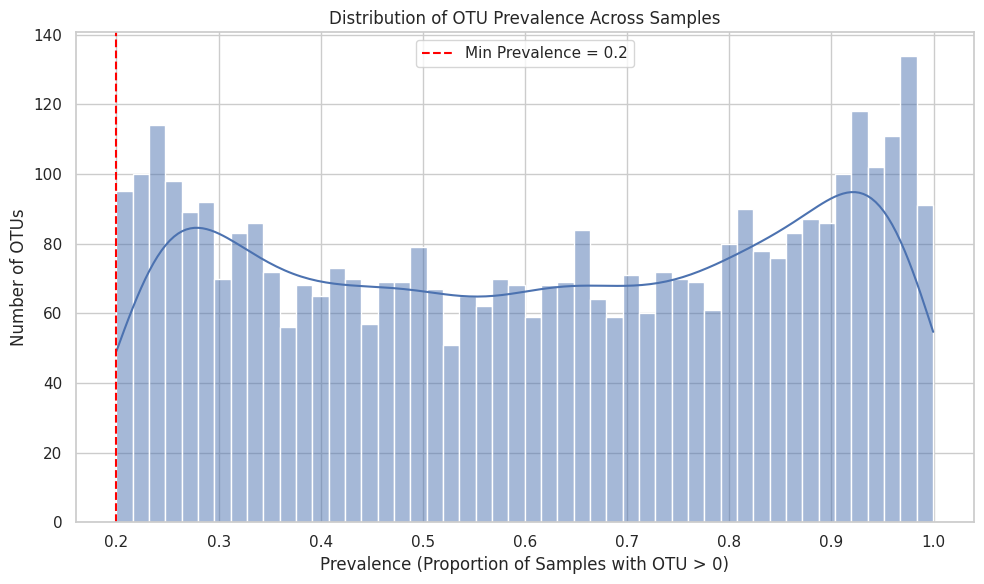

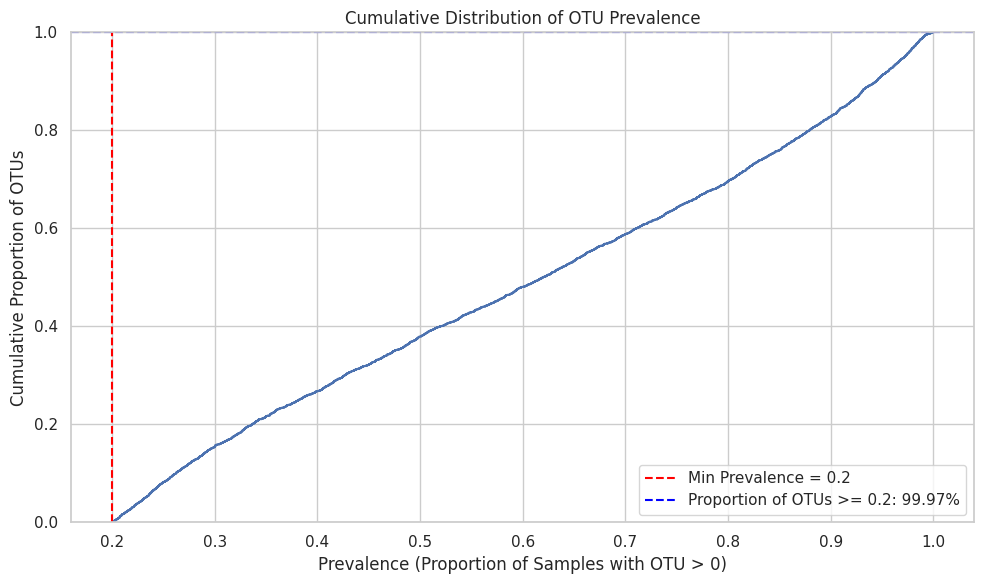

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate prevalence (proportion of samples where OTU count > 0)
n_samples = otu_table.shape[1]
prevalence = (otu_table > 0).sum(axis=1) / n_samples

# Apply prevalence filter (min_prevalence = 0.20)
min_prevalence = 0.20
min_samples = int(min_prevalence * n_samples)
prevalence_filter = (otu_table > 0).sum(axis=1) >= min_samples
filtered_otu_table = otu_table[prevalence_filter]
print(f"After prevalence filter (>= {min_samples} samples): {filtered_otu_table.shape}")

# Plot 1: Histogram of Prevalence
plt.figure(figsize=(10, 6))
sns.histplot(prevalence, bins=50, kde=True)
plt.axvline(x=min_prevalence, color='red', linestyle='--', label=f'Min Prevalence = {min_prevalence}')
plt.title('Distribution of OTU Prevalence Across Samples')
plt.xlabel('Prevalence (Proportion of Samples with OTU > 0)')
plt.ylabel('Number of OTUs')
plt.legend()
plt.tight_layout()
plt.savefig('otu_prevalence_histogram.png')
plt.show()

# Plot 2: Cumulative Distribution Plot
plt.figure(figsize=(10, 6))
sns.ecdfplot(prevalence)
plt.axvline(x=min_prevalence, color='red', linestyle='--', label=f'Min Prevalence = {min_prevalence}')
plt.axhline(y=(prevalence >= min_prevalence).mean(), color='blue', linestyle='--', 
            label=f'Proportion of OTUs >= {min_prevalence}: {((prevalence >= min_prevalence).mean()):.2%}')
plt.title('Cumulative Distribution of OTU Prevalence')
plt.xlabel('Prevalence (Proportion of Samples with OTU > 0)')
plt.ylabel('Cumulative Proportion of OTUs')
plt.legend()
plt.tight_layout()
plt.savefig('otu_prevalence_ecdf.png')
plt.show()

In [117]:
otu_table

,ERR9830102,SRR11047639,SRR413668,ERR1398259,ERR479055,ERR527155,SRR27644834,SRR21968734,SRR5650030,ERR1398117,...,ERR1913263,SRR5650168,SRR19064528,SRR5650167,ERR481084,ERR527082,SRR28565219,ERR479174,ERR2738751,ERR1913262
UBA1436_sp002329395,0,0,0,0,0,0,0,16,10,0,...,0,0,13,0,0,0,0,0,10,0
UBA1174_sp900556855,0,0,0,0,0,0,65,0,0,0,...,0,39,0,0,0,79,0,0,0,0
HGM14224_sp900761905,0,0,0,0,42,0,0,0,0,0,...,126,13,18,106,0,7292,0,230,0,133
UBA4248_sp004554395,0,0,0,0,11,19,47,0,129,109,...,0,0,48,0,0,24,0,0,0,0
Campylobacter_B_hominis,10,0,0,139,15,23,35,0,0,222,...,0,20,0,0,0,16,841,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ruminococcus_E_bromii_A,143,69,118,29,2897,1396,1876,205,1660,14,...,0,1092,1666,249,66,836,0,3772,157,0
Ruminococcus_E_sp003526955,0,0,49,29,3933,485,403333,0,1706,0,...,71,310194,1857,227,77,200774,0,14947,0,71
Ruminococcus_E_sp003438075,1079,37,772,143,52601,1541,77823,87,16290,0,...,60,41231,7533,1350,405,34539,0,7705,0,43
Ruminococcus_E_bromii,29,0,94,1628,271371,47556,4438,0,94367,0,...,786,1581,190285,76614,4854,1242,22,218628,0,765


In [118]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from skbio.stats.composition import clr, multiplicative_replacement
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [119]:
otu_table = otu_table.T
print(f"Transposed OTU table shape: {otu_table.shape}")
otu_table

Transposed OTU table shape: (7116, 3930)


,UBA1436_sp002329395,UBA1174_sp900556855,HGM14224_sp900761905,UBA4248_sp004554395,Campylobacter_B_hominis,Campylobacter_B_sp900539505,MGYG000002669,Bruticola_sp900772775,Bruticola_sp004554425,Brachyspira_pilosicoli,...,MGYG000003112,Ruminococcus_E_sp003521625,Ruminococcus_E_sp002493635,Ruminococcus_E_sp900543095,Ruminococcus_E_sp900755995,Ruminococcus_E_bromii_A,Ruminococcus_E_sp003526955,Ruminococcus_E_sp003438075,Ruminococcus_E_bromii,Ruminococcus_E_bromii_B
ERR9830102,0,0,0,0,10,0,0,0,146,0,...,789,0,115,0,46,143,0,1079,29,60
SRR11047639,0,0,0,0,0,0,0,0,53,0,...,169,0,15,0,16,69,0,37,0,23
SRR413668,0,0,0,0,0,0,441,367,25,82,...,262,0,214,23,112,118,49,772,94,161
ERR1398259,0,0,0,0,139,52,0,0,27,15,...,5719,0,19,13,23,29,29,143,1628,4508
ERR479055,0,0,42,11,15,21,0,10,40,21,...,838,3368,1569,826,2727,2897,3933,52601,271371,791291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ERR527082,0,79,7292,24,16,0,65,12,501,16,...,1451,232,751,329,3805,836,200774,34539,1242,623
SRR28565219,0,0,0,0,841,0,0,0,0,0,...,11,0,10,0,0,0,0,0,22,60
ERR479174,0,0,230,0,0,0,0,0,208,11,...,1591,778,1663,1645,4477,3772,14947,7705,218628,576146
ERR2738751,10,0,0,0,0,0,0,0,58,0,...,250,0,88,0,12,157,0,0,0,27


In [123]:

metadata = pd.read_csv("metadata_filtered_7116.tsv",sep="\t")
metadata['Class_Label'] = (metadata['Health_status'] == 'HEALTHY').astype(int)

assert set(otu_table.index) == set(metadata['Run_ID'])
# Sort metadata to match OTU table index
metadata = metadata.set_index('Run_ID').loc[otu_table.index]
metadata

,BioProject,BioSample,Health_status,Phenotype,Full_Name,Sex,Location,Sample,Platform,BMI,Author,Class_Label
ERR9830102,PRJEB53401,SAMEA110061133,HEALTHY,Healthy,Healthy,MALE,USA,Stool,Illumina NextSeq 550,"230,449,827","Boktor et al.,(2023)",1
SRR11047639,PRJNA598446,SAMN13705428,NON-HEALTHY,RA,Rheumatoid arthritis,FEMALE,USA,Stool,Illumina HiSeq 4000,NaN,"Gupta et al,2021)",0
SRR413668,PRJNA422434,SAMN00792013,HEALTHY,Healthy,Healthy,MALE,China,Stool,Illumina Genome Analyzer II,NaN,"Qin et al,2012)",1
ERR1398259,PRJEB13870,SAMEA3951684,NON-HEALTHY,HTN,Hypertension,NaN,China,Stool,Illumina,NaN,"Li et al,2017)",0
ERR479055,PRJEB6070,SAMEA2466904,NON-HEALTHY,CRC,Colorectal Cancer,FEMALE,France,Stool,Illumina HiSeq 2000,37,"Zeller et al.,(2014)",0
...,...,...,...,...,...,...,...,...,...,...,...,...
ERR527082,PRJEB6337,SAMEA2581912,HEALTHY,Healthy,Healthy,FEMALE,China,Stool,Illumina,20.32,"Qin et al.,(2014)",1
SRR28565219,PRJNA1096686,SAMN40759262,NON-HEALTHY,UC,Ulcerative Colitis,MALE,USA,Stool,Illumina NovaSeq X,NaN,"E. Krueger et al.,(2024)",0
ERR479174,PRJEB6070,SAMEA2467002,NON-HEALTHY,CRC,Colorectal Cancer,MALE,France,Stool,Illumina HiSeq 2000,24,"Zeller et al.,(2014)",0
ERR2738751,PRJEB28237,SAMEA4833069,NON-HEALTHY,ABx,Antibiotic exposer,NaN,Canada,Stool,Illumina,NaN,"Raymond et al,2019)",0


In [124]:

# Extract target variable (ClassLabel)
y = metadata['Class_Label'].values
y

array([1, 0, 1, ..., 0, 0, 0])

In [125]:

# CLR normalization
# Handle zeros with multiplicative replacement
otu_table_no_zeros = multiplicative_replacement(otu_table.values)
# Apply CLR transformation
X_clr = clr(otu_table_no_zeros)
X_clr

/lustrehome/babluuniba2022/miniconda3/envs/ml/lib/python3.11/site-packages/skbio/util/_warning.py:40: DeprecationWarning: `multiplicative_replacement` was renamed to `multi_replace` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)


array([[-2.70762496, -2.70762496, -2.70762496, ...,  5.11361126,
         1.49711712,  2.22416585],
       [-2.68426342, -2.68426342, -2.68426342, ...,  2.89430885,
        -2.68426342,  2.41888515],
       [-2.87935518, -2.87935518, -2.87935518, ...,  3.17022307,
         1.0645333 ,  1.60264289],
       ...,
       [-4.1721811 , -4.1721811 ,  1.22228505, ...,  4.73383049,
         8.07933267,  9.04832212],
       [ 0.65478277, -2.71673364, -2.71673364, ..., -2.71673364,
        -2.71673364,  1.64803454],
       [-2.6277017 , -2.6277017 ,  5.10718427, ...,  3.97803526,
         6.85671098,  7.94920437]])

In [ ]:


# L1-regularized logistic regression with cross-validation
logistic_l1 = LogisticRegressionCV(
    Cs=10,  # Test 10 values for C (inverse of regularization strength)
    cv=5,   # 5-fold cross-validation
    penalty='l1',
    solver='liblinear',  # Required for L1 penalty
    random_state=42,
    max_iter=2000,
    multi_class='auto'  # Handles binary or multiclass
)
logistic_l1.fit(X_clr, y)

optimal_C = logistic_l1.C_[0]
print(f"Optimal C: {optimal_C}")

# Get selected features (OTUs with non-zero coefficients)
selected_features = otu_table.columns[logistic_l1.coef_[0] != 0].tolist()
selected_coefficients = logistic_l1.coef_[0][logistic_l1.coef_[0] != 0]
print(f"Number of selected OTUs: {len(selected_features)}")

# Save selected OTUs and coefficients
selected_otus = pd.DataFrame({
    'OTU': selected_features,
    'Coefficient': selected_coefficients
})
selected_otus.to_csv("selected_otus_logistic_l1.csv", index=False)
print("Selected OTUs saved to 'selected_otus_logistic_l1.csv'")

# Plot number of selected features vs. C
Cs = np.logspace(-4, 2, 50)
n_features = []
for C in Cs:
    model = LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=2000, multi_class='auto')
    model.fit(X, y)
    n_features.append(np.sum(model.coef_[0] != 0))

plt.figure(figsize=(8, 6))
plt.semilogx(Cs, n_features, '-o')
plt.axvline(optimal_C, color='red', linestyle='--', label=f'Optimal C = {optimal_C:.2e}')
plt.xlabel('C (Inverse of Regularization Strength)')
plt.ylabel('Number of Selected OTUs')
plt.title('Number of Selected OTUs vs. Logistic L1 Regularization Strength')
plt.legend()
plt.tight_layout()
plt.savefig('lasso_feature_selection.png')
plt.show()

print("\nTop 10 OTUs by absolute coefficient:")
print(selected_otus.sort_values(by='Coefficient', key=abs, ascending=False).head(10))

/lustrehome/babluuniba2022/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1903: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [127]:
selected_otus

,OTU,Coefficient
0,UBA1174_sp900556855,-0.046414
1,HGM14224_sp900761905,0.005243
2,Campylobacter_B_hominis,-0.001842
3,MGYG000002669,0.022653
4,Treponema_D_sp002449305,0.027592
...,...,...
1513,Eubacterium_R_sp000434995,0.018422
1514,Pseudoruminococcus_massiliensis,-0.009182
1515,MGYG000003112,0.038075
1516,Ruminococcus_E_bromii_A,-0.057500
